In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("retail_store_sales.csv")
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,4/8/2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,7/23/2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,10/5/2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,5/7/2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,10/2/2022,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,9/3/2023,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,8/12/2022,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,8/24/2024,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,12/30/2023,True


In [147]:
df["Price Per Unit"].value_counts()

df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Total Spent"] / df["Quantity"])
df["Price Per Unit"].isnull().sum()


np.int64(0)

In [148]:
df["Quantity"].isnull().sum()
df["Quantity"]=df["Quantity"].fillna(df["Total Spent"]/df["Price Per Unit"])
df["Quantity"].isnull().sum()


np.int64(604)

In [149]:
print(df[df["Quantity"].isna()][["Price Per Unit", "Total Spent", "Quantity"]])

       Price Per Unit  Total Spent  Quantity
7                33.5          NaN       NaN
15               24.5          NaN       NaN
19               35.0          NaN       NaN
25               39.5          NaN       NaN
34               23.0          NaN       NaN
...               ...          ...       ...
12527             5.0          NaN       NaN
12552             8.0          NaN       NaN
12556            41.0          NaN       NaN
12562            33.5          NaN       NaN
12564            29.0          NaN       NaN

[604 rows x 3 columns]


In [150]:
df = df.dropna(subset=["Price Per Unit", "Total Spent", "Quantity"])

df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 11971 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  str    
 1   Customer ID       11971 non-null  str    
 2   Category          11971 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  str    
 8   Location          11971 non-null  str    
 9   Transaction Date  11971 non-null  str    
 10  Discount Applied  7983 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [151]:

df["Item"]=df["Item"].fillna("unknown_items")
df["Discount Applied"]=df["Discount Applied"].fillna(True)
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,4/8/2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,7/23/2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,10/5/2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,5/7/2022,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,10/2/2022,False


In [152]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 11971 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  str    
 1   Customer ID       11971 non-null  str    
 2   Category          11971 non-null  str    
 3   Item              11971 non-null  str    
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  str    
 8   Location          11971 non-null  str    
 9   Transaction Date  11971 non-null  str    
 10  Discount Applied  11971 non-null  object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [153]:
df["Price Per Unit"].unique()
df["Quantity"].unique()
df["Total Spent"].unique()
df["Discount Applied"]=df["Discount Applied"].astype(int)
df["Discount Applied"].unique()


array([1, 0])

In [154]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df["Transaction Date"] = df["Transaction Date"].dt.strftime("%d-%m-%Y")
df["Transaction Date"].unique()
df["Transaction Date"].isnull().sum()



np.int64(0)

In [155]:
df = df.dropna(subset=["Transaction Date"])
df.info()

<class 'pandas.DataFrame'>
Index: 11971 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  str    
 1   Customer ID       11971 non-null  str    
 2   Category          11971 non-null  str    
 3   Item              11971 non-null  str    
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  str    
 8   Location          11971 non-null  str    
 9   Transaction Date  11971 non-null  str    
 10  Discount Applied  11971 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 1.1 MB


In [156]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], dayfirst=True, errors="coerce")

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

df["Day"] = df["Transaction Date"].dt.day
df["Month"] = df["Transaction Date"].dt.month
df["Month Name"] = df["Transaction Date"].dt.month_name()
df["Year"] = df["Transaction Date"].dt.year
print(df.head())


  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

   Discount Applied  Day  Month Month Name  Year  
0                 1    8      4      April  2024  
1             

Category
Beverages                             197047.5
Butchers                              208118.0
Computers and electric accessories    190692.5
Electric household essentials         203813.5
Food                                  194812.0
Furniture                             195310.0
Milk Products                         180112.0
Patisserie                            182165.5
Name: Total Spent, dtype: float64


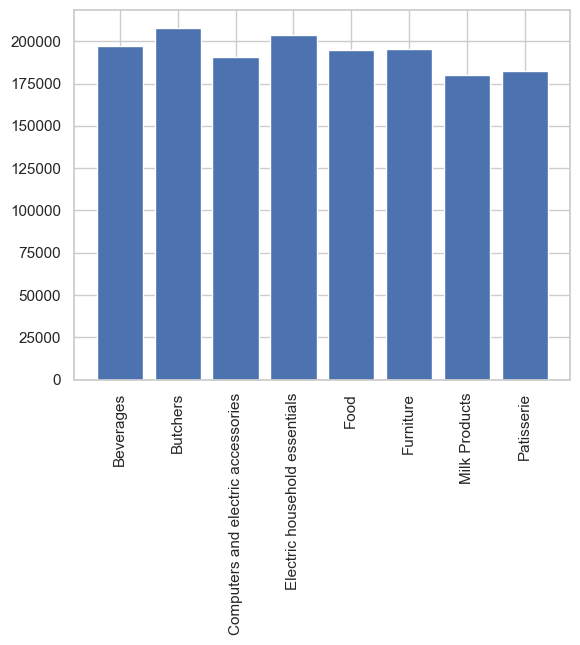

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Day,Month,Month Name,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,8,4,April,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,23,7,July,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,5,10,October,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,7,5,May,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,2,10,October,2022


In [157]:
dpi = 300

salesbycategory = df.groupby("Category")["Total Spent"].sum()

print(salesbycategory)

plt.bar(salesbycategory.index, salesbycategory.values)
plt.xticks(rotation=90)
plt.show()

df.head()

In [158]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Day,Month,Month Name,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,8,4,April,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,23,7,July,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,5,10,October,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,7,5,May,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,2,10,October,2022


In [159]:
df.info
df.columns
# df["Month"]=df["Month"].unique()
df.columns



Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied', 'Day', 'Month', 'Month Name',
       'Year'],
      dtype='str')

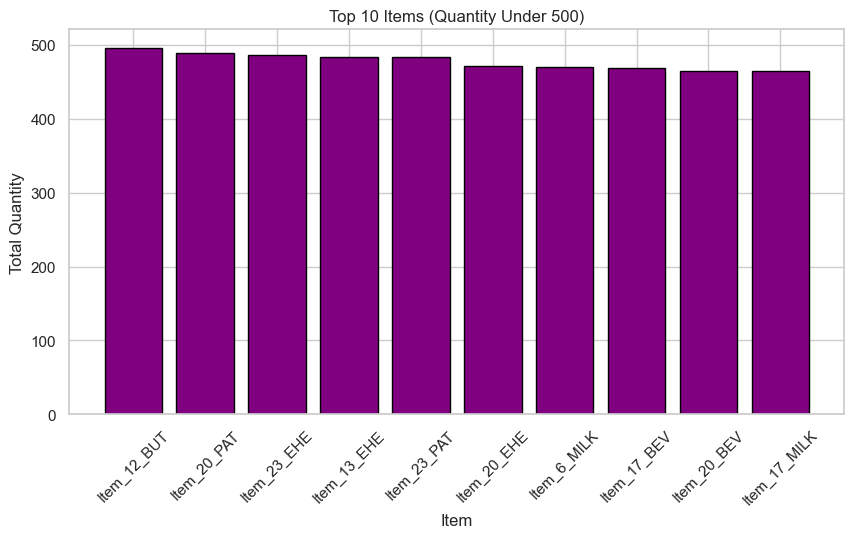

In [160]:
items = df.groupby("Item")["Quantity"].sum()


items = items[items < 500]

top10 = items.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values, color="purple", edgecolor="black")
plt.xticks(rotation=45)
plt.xlabel("Item")
plt.ylabel("Total Quantity")
plt.title("Top 10 Items (Quantity Under 500)")
plt.show()


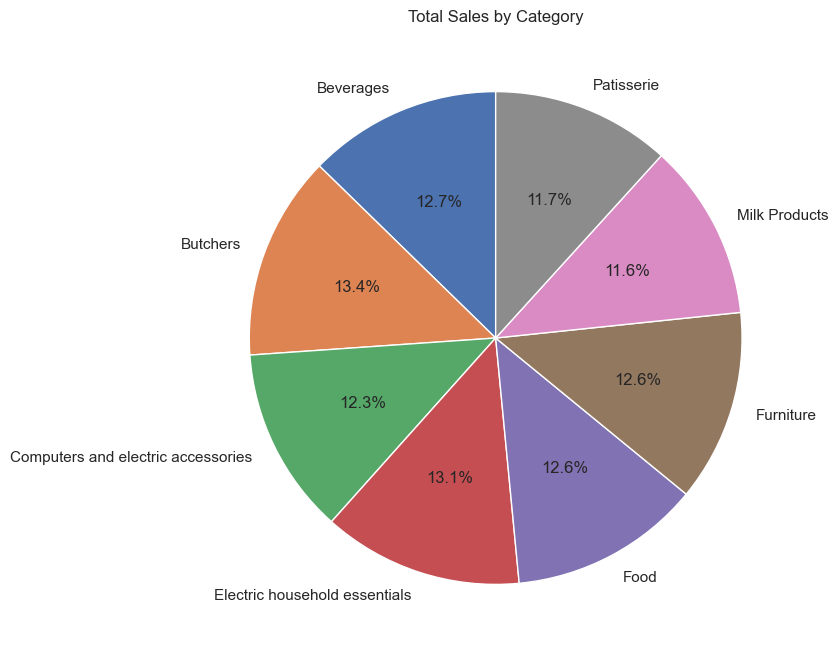

In [161]:
sales = df.groupby("Category")["Total Spent"].sum()

plt.figure(figsize=(8,8))
plt.pie(sales.values,
        labels=sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Total Sales by Category")
plt.show()

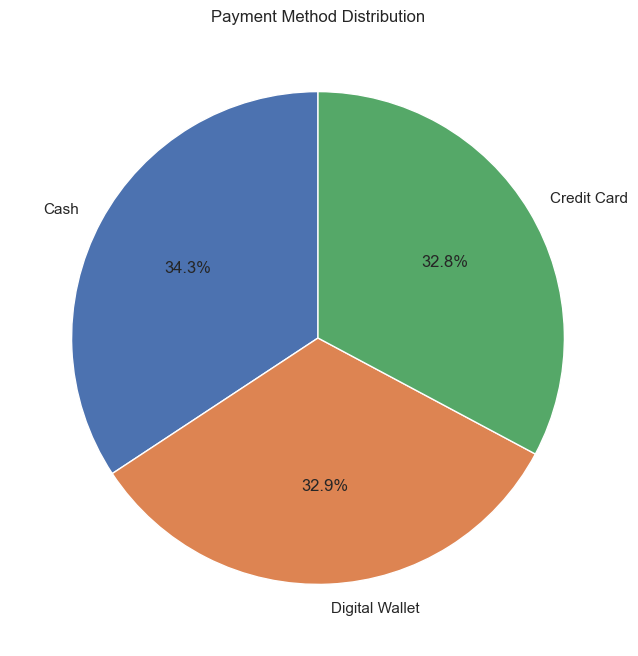

In [162]:
payment = df["Payment Method"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(payment.values,
        labels=payment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Method Distribution")
plt.show()

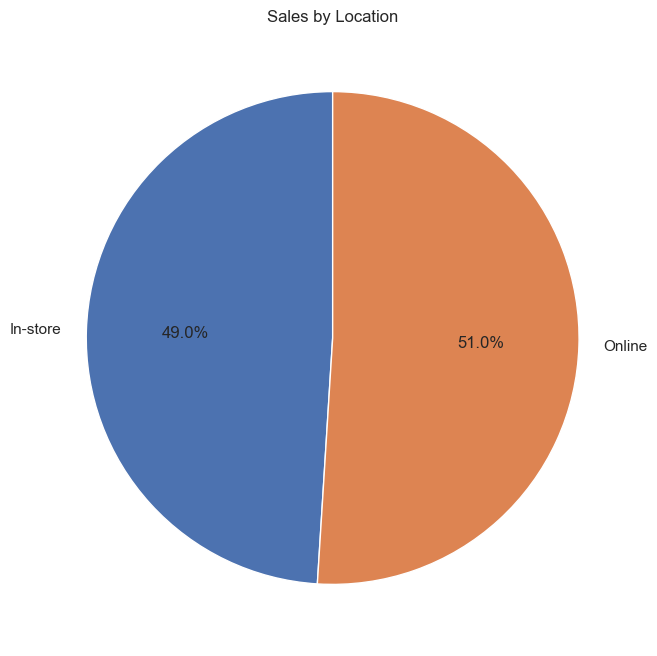

In [163]:
location = df.groupby("Location")["Total Spent"].sum()

plt.figure(figsize=(8,8))
plt.pie(location.values,
        labels=location.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Sales by Location")
plt.show()

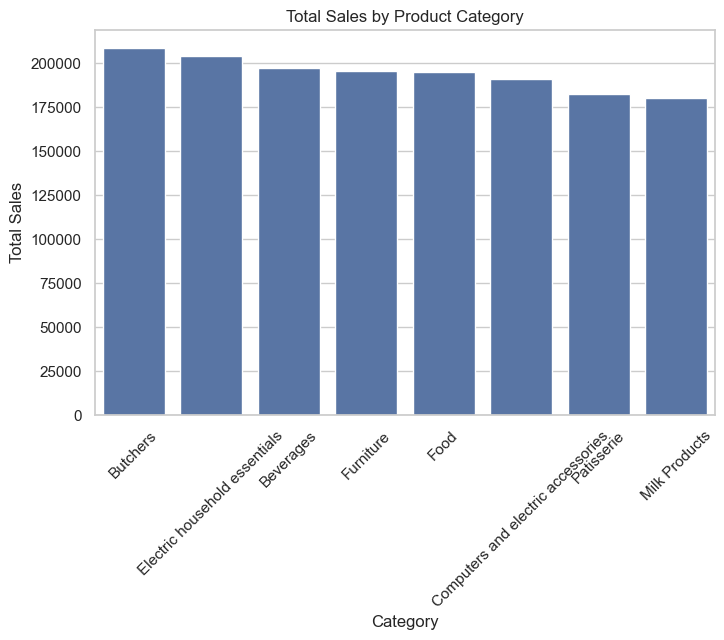

In [164]:
category_sales = (
    df.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x="Category", y="Total Spent")

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

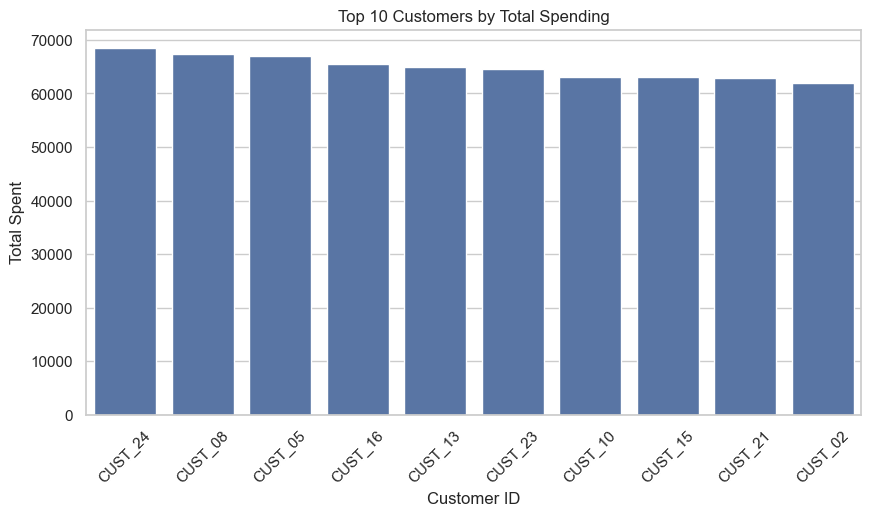

In [165]:
top_customers = (
    df.groupby("Customer ID")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_customers,
            x="Customer ID",
            y="Total Spent")

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.show()

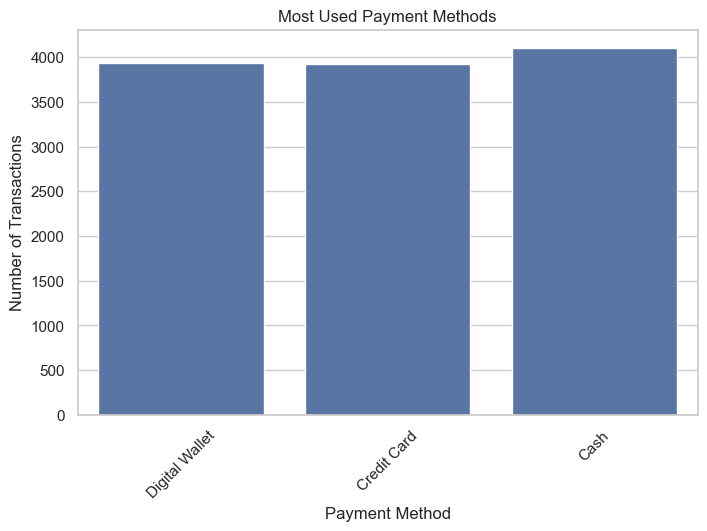

In [166]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Payment Method")

plt.title("Most Used Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

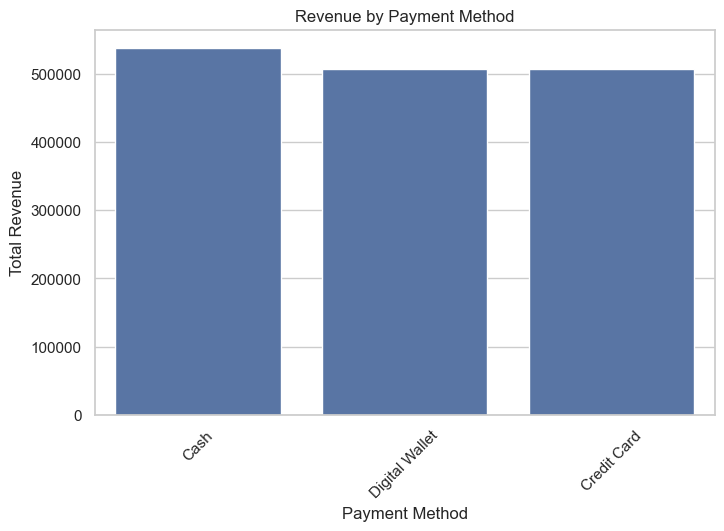

In [167]:
payment_sales = (
    df.groupby("Payment Method")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(data=payment_sales,
            x="Payment Method",
            y="Total Spent")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

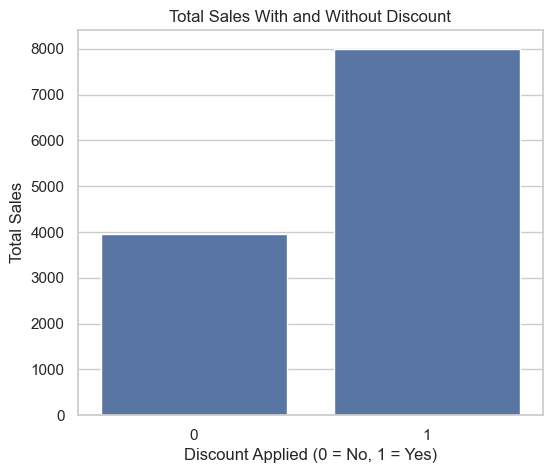

In [168]:
discount_sales = (
    df.groupby("Discount Applied")["Total Spent"]
    .count()
    .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=discount_sales,
    x="Discount Applied",
    y="Total Spent"
)

plt.title("Total Sales With and Without Discount")
plt.xlabel("Discount Applied (0 = No, 1 = Yes)")
plt.ylabel("Total Sales")
plt.show()

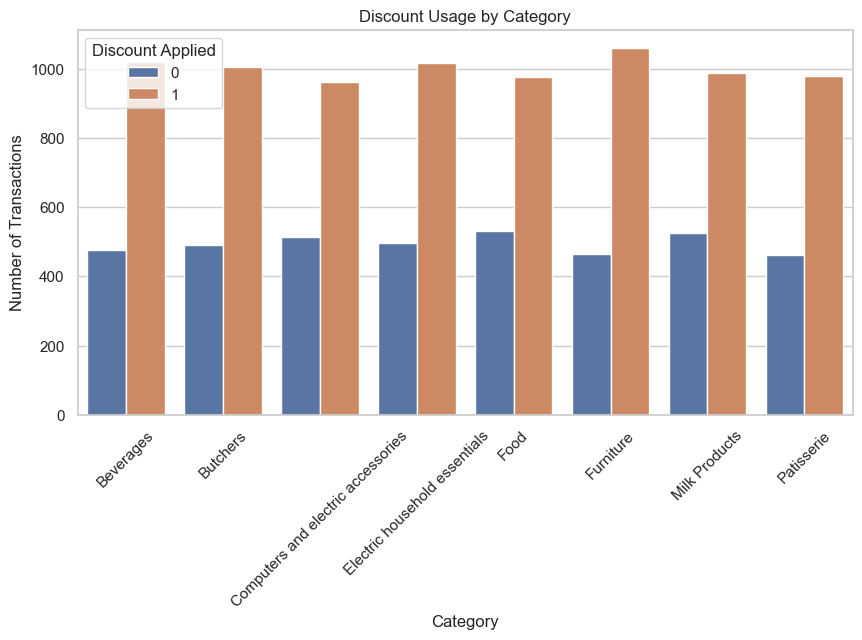

In [169]:
category_discount = (
    df.groupby(["Category", "Discount Applied"])
    .size()
    .reset_index(name="Count")
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=category_discount,
    x="Category",
    y="Count",
    hue="Discount Applied"
)

plt.title("Discount Usage by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.legend(title="Discount Applied")
plt.show()

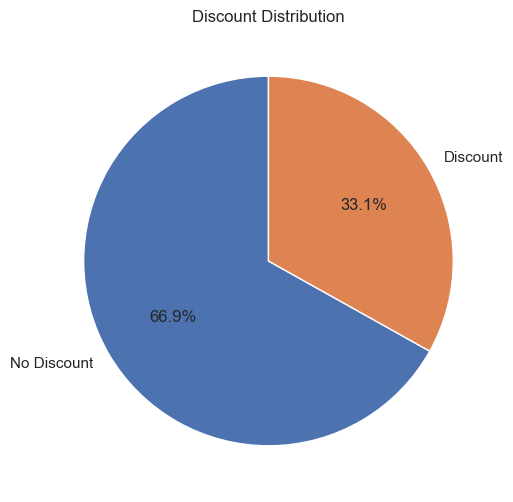

In [170]:
discount_count = df["Discount Applied"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    discount_count,
    labels=["No Discount", "Discount"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Discount Distribution")
plt.show()

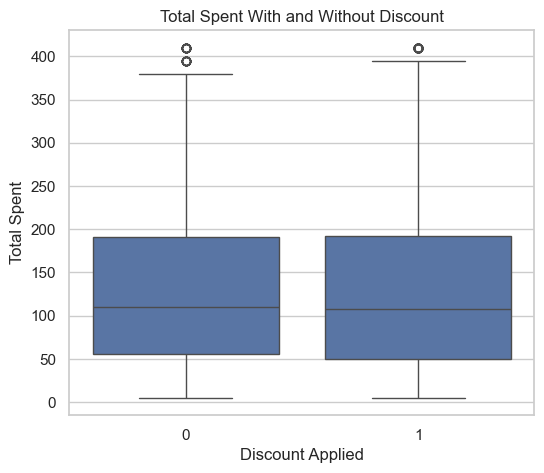

In [171]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Discount Applied",
    y="Total Spent"
)

plt.title("Total Spent With and Without Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Total Spent")
plt.show()

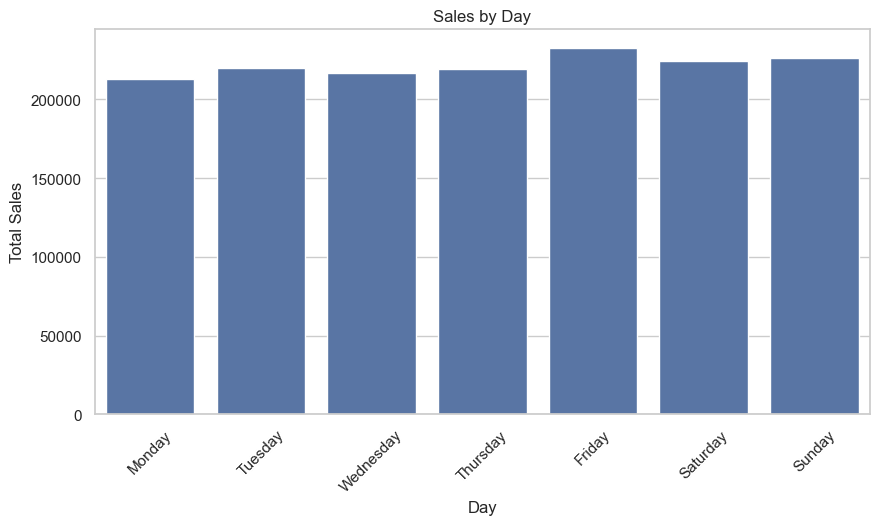

In [172]:
df["Day"] = df["Transaction Date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_sales = (
    df.groupby("Day")["Total Spent"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=day_sales,
    x="Day",
    y="Total Spent"
)

plt.title("Sales by Day")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

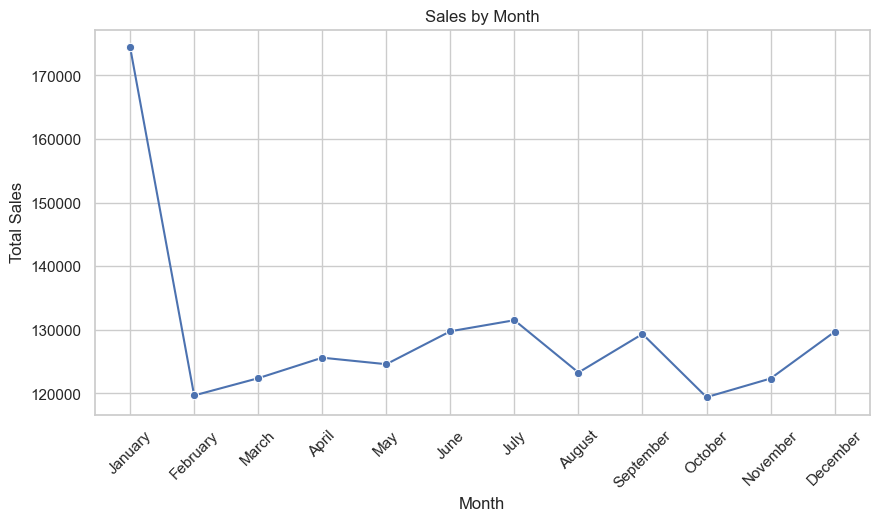

In [173]:
# Extract month name
df["Month"] = df["Transaction Date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

month_sales = (
    df.groupby("Month")["Total Spent"]
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=month_sales,
    x="Month",
    y="Total Spent",
    marker="o"
)

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

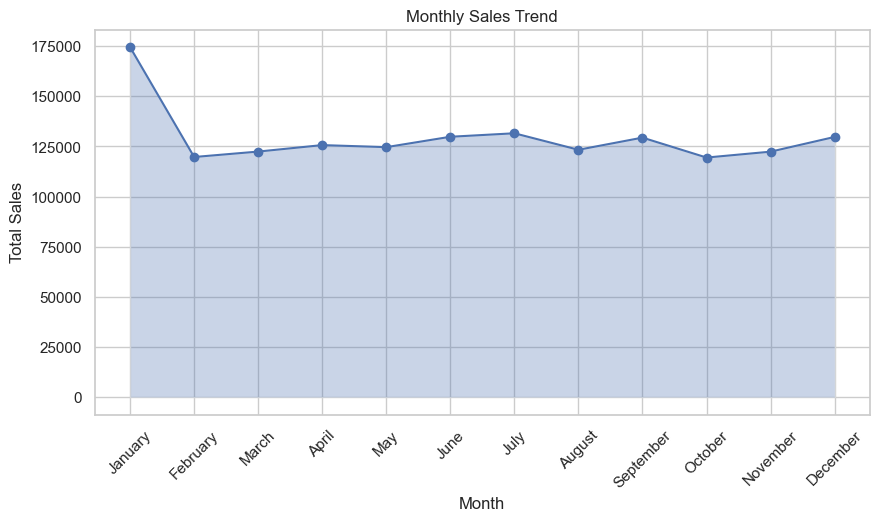

In [174]:
plt.figure(figsize=(10,5))

sns.set_theme(style="whitegrid")

plt.plot(
    month_sales["Month"],
    month_sales["Total Spent"],
    marker="o"
)

plt.fill_between(
    month_sales["Month"],
    month_sales["Total Spent"],
    alpha=0.3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()